# Anatomy of a Flop — Error Analysis

## Scopul
Analizăm în profunzime erorile modelului câștigător — **Gradient Boosting**.

### Pași:
1. Distribuția reziduurilor
2. Predicted vs Actual
3. Heteroscedasticity check
4. Corelația erorilor cu variabilele independente
5. Filmele cel mai greșit prezise

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, r2_score
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8')
sns.set_palette('husl')

df = pd.read_csv('../data/movies_clean.csv')

features = ['budget', 'vote_average', 'vote_count',
            'popularity', 'runtime', 'release_year', 'release_month']

X = df[features]
y = df['disappointment_index']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

gb = GradientBoostingRegressor(n_estimators=100, random_state=42)
gb.fit(X_train, y_train)
y_pred = gb.predict(X_test)

residuals = y_test - y_pred

print(f" Model reantrenat — Gradient Boosting")
print(f"   R²   = {r2_score(y_test, y_pred):.4f}")
print(f"   RMSE = {np.sqrt(mean_squared_error(y_test, y_pred)):.4f}")

 Model reantrenat — Gradient Boosting
   R²   = 0.4939
   RMSE = 5.8106


## 1. Distribuția Reziduurilor

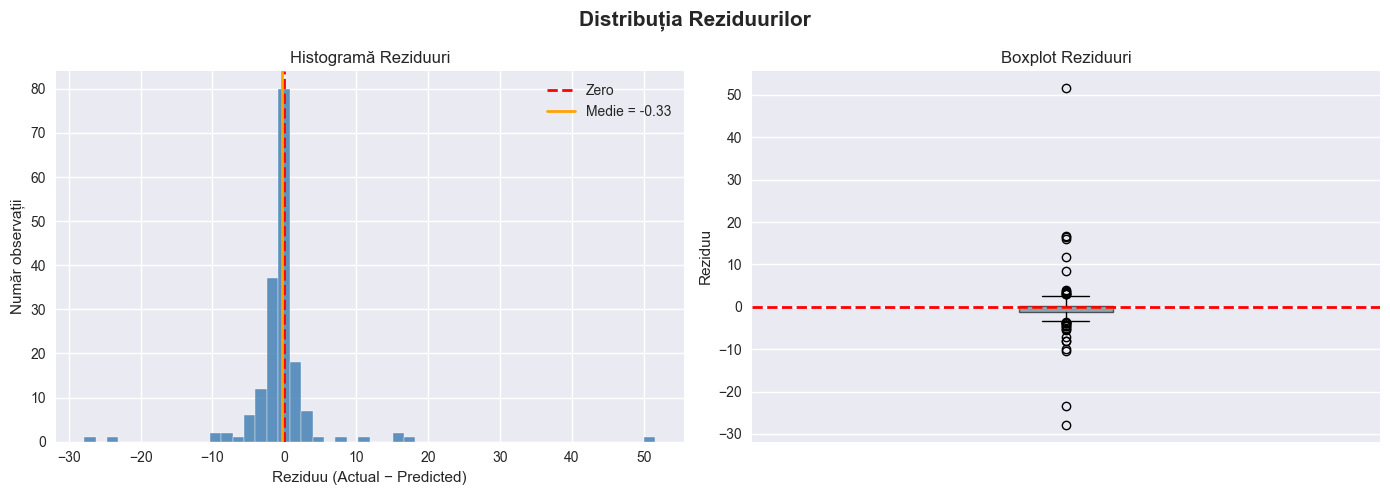

Statistici reziduuri:
   Medie:       -0.3277
   Mediană:     -0.5076
   Std:         5.8180
   Min:         -27.8552
   Max:         51.6156
   Erori < 2:   76.4% din cazuri


In [3]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Distribuția Reziduurilor', fontsize=15, fontweight='bold')

axes[0].hist(residuals, bins=50, color='steelblue', edgecolor='white', alpha=0.85)
axes[0].axvline(x=0, color='red', linestyle='--', linewidth=2, label='Zero')
axes[0].axvline(x=residuals.mean(), color='orange', linestyle='-',
                linewidth=2, label=f'Medie = {residuals.mean():.2f}')
axes[0].set_title('Histogramă Reziduuri')
axes[0].set_xlabel('Reziduu (Actual − Predicted)')
axes[0].set_ylabel('Număr observații')
axes[0].legend()

axes[1].boxplot(residuals, vert=True, patch_artist=True,
                boxprops=dict(facecolor='steelblue', alpha=0.6))
axes[1].axhline(y=0, color='red', linestyle='--', linewidth=2)
axes[1].set_title('Boxplot Reziduuri')
axes[1].set_ylabel('Reziduu')
axes[1].set_xticks([])

plt.tight_layout()
plt.savefig('../data/residuals_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Statistici reziduuri:")
print(f"   Medie:       {residuals.mean():.4f}")
print(f"   Mediană:     {residuals.median():.4f}")
print(f"   Std:         {residuals.std():.4f}")
print(f"   Min:         {residuals.min():.4f}")
print(f"   Max:         {residuals.max():.4f}")
print(f"   Erori < 2:   {(abs(residuals) < 2).mean()*100:.1f}% din cazuri")